# Frame Camera Mission Planning

**Purpose:** This notebook demonstrates how to plan aerial photography missions using HyPlan's `FrameCamera` sensor class. Frame cameras capture full 2D images in a single exposure, making them the standard tool for photogrammetric mapping, orthomosaic generation, and high-resolution land cover assessment. Planning a frame camera survey requires balancing ground sample distance (resolution), footprint size (coverage per frame), frame rate, and aircraft speed to achieve the desired overlap between consecutive images.

| | |
|---|---|
| **Audience** | Beginner |
| **Runtime** | ~1 minute |
| **Requires internet** | No |
| **Credentials required** | None |
| **Optional dependencies** | None |
| **Uses example data** | No (generates synthetic scenarios) |

**What You Will Learn:**
- How frame cameras differ from line scanners and how that affects flight planning
- How focal length, sensor size, and altitude determine GSD and footprint
- How to compute the required altitude for a target GSD
- How to determine the critical ground speed for contiguous along-track coverage
- How focal length trades off resolution against field of view
- How to integrate frame camera parameters with flight lines for survey planning

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd

from hyplan.instruments import FrameCamera
from hyplan.flight_line import FlightLine
from hyplan.units import ureg


## 1. Define a Frame Camera

A `FrameCamera` is defined by its physical sensor dimensions, focal length,
pixel resolution, frame rate, and f-number. These are typical parameters
for a medium-format aerial mapping camera.

**Frame cameras vs. line scanners:** A line scanner (pushbroom) builds an image one cross-track line at a time as the aircraft moves forward; its along-track coverage is continuous and limited only by flight duration. A frame camera, by contrast, captures a complete 2D image (a "frame") at each shutter trigger. This means along-track coverage depends on the frame rate and aircraft speed: if the aircraft moves too fast between frames, there will be gaps. The fundamental planning parameters are therefore different:

| Parameter | Line Scanner | Frame Camera |
|-----------|-------------|--------------|
| Cross-track coverage | Swath width (fixed by optics) | Footprint width (fixed by optics) |
| Along-track coverage | Continuous | Discrete frames; depends on frame rate and speed |
| Overlap control | Line spacing only (side overlap) | Both forward overlap (speed/frame rate) and side overlap (line spacing) |
| Speed constraint | Integration time / SNR | Frame rate / forward overlap requirement |

In [2]:
# Medium-format mapping camera
mapping_cam = FrameCamera(
    name="PhaseOne iXM-100",
    sensor_width=ureg.Quantity(53.4, "mm"),
    sensor_height=ureg.Quantity(40.0, "mm"),
    focal_length=ureg.Quantity(50.0, "mm"),
    resolution_x=11664,
    resolution_y=8750,
    frame_rate=ureg.Quantity(1.5, "Hz"),
    f_speed=4.0,
)

print(f"Camera: {mapping_cam.name}")
print(f"  Sensor:      {mapping_cam.sensor_width} x {mapping_cam.sensor_height}")
print(f"  Focal length: {mapping_cam.focal_length}")
print(f"  Resolution:  {mapping_cam.resolution_x} x {mapping_cam.resolution_y}")
print(f"  Frame rate:  {mapping_cam.frame_rate}")
print(f"  f-number:    f/{mapping_cam.f_speed}")
print(f"  FOV (H):     {mapping_cam.fov_x:.1f} deg")
print(f"  FOV (V):     {mapping_cam.fov_y:.1f} deg")

Camera: PhaseOne iXM-100
  Sensor:      53.4 millimeter x 40.0 millimeter
  Focal length: 50.0 millimeter
  Resolution:  11664 x 8750
  Frame rate:  1.5 hertz
  f-number:    f/4.0
  FOV (H):     56.2 deg
  FOV (V):     43.6 deg


## 2. Ground Sample Distance and Footprint

GSD tells you the physical size of a pixel on the ground. The footprint
is the total area captured per frame. Both scale linearly with altitude.

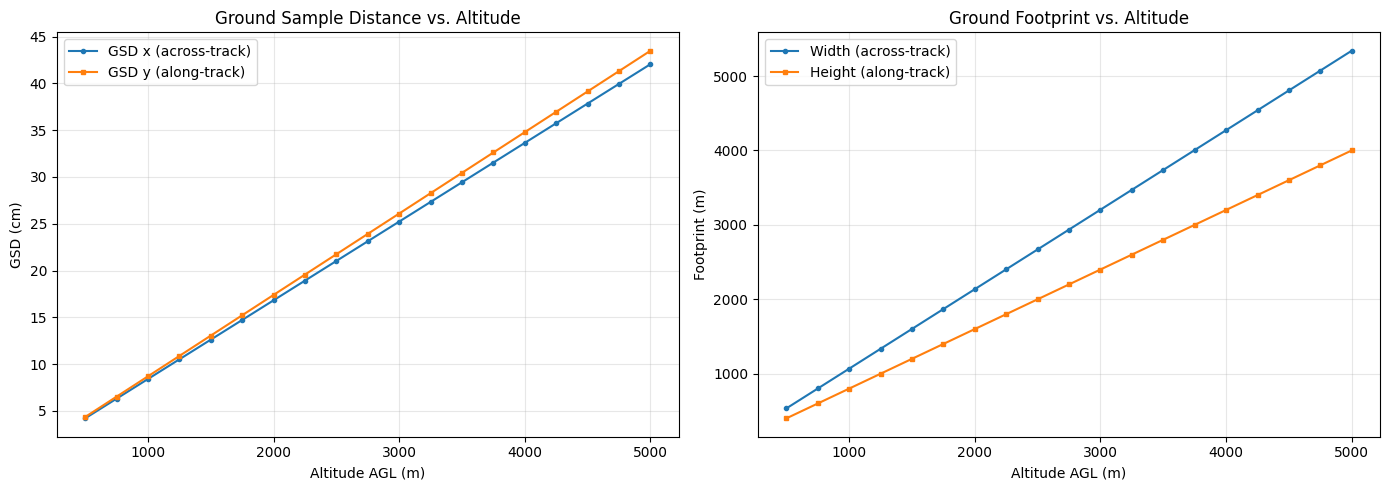

In [3]:
altitudes_m = np.arange(500, 5001, 250)

gsd_x_vals = []
gsd_y_vals = []
fp_width_vals = []
fp_height_vals = []

for alt in altitudes_m:
    alt_q = ureg.Quantity(alt, "meter")
    gsd = mapping_cam.ground_sample_distance(alt_q)
    fp = mapping_cam.footprint_at(alt_q)
    gsd_x_vals.append(gsd["x"].to(ureg.cm).magnitude)
    gsd_y_vals.append(gsd["y"].to(ureg.cm).magnitude)
    fp_width_vals.append(fp["width"].to(ureg.meter).magnitude)
    fp_height_vals.append(fp["height"].to(ureg.meter).magnitude)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(altitudes_m, gsd_x_vals, "o-", markersize=3, label="GSD x (across-track)")
axes[0].plot(altitudes_m, gsd_y_vals, "s-", markersize=3, label="GSD y (along-track)")
axes[0].set_xlabel("Altitude AGL (m)")
axes[0].set_ylabel("GSD (cm)")
axes[0].set_title("Ground Sample Distance vs. Altitude")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(altitudes_m, fp_width_vals, "o-", markersize=3, label="Width (across-track)")
axes[1].plot(altitudes_m, fp_height_vals, "s-", markersize=3, label="Height (along-track)")
axes[1].set_xlabel("Altitude AGL (m)")
axes[1].set_ylabel("Footprint (m)")
axes[1].set_title("Ground Footprint vs. Altitude")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Altitude for a Target GSD

Given a desired GSD, compute the required flight altitude. This is
the inverse of the GSD calculation.

This is the most common starting point for frame camera planning: the science or mapping requirement specifies a minimum GSD (e.g., "5 cm pixels"), and the planner works backwards to determine the required altitude, which in turn determines the footprint size and the number of flight lines needed.

## 3. Altitude for a Target GSD

Given a desired GSD, compute the required flight altitude. This is
the inverse of the GSD calculation.

## 4. Critical Ground Speed and Overlap Requirements

The critical ground speed is the maximum speed at which consecutive frames
still provide contiguous along-track coverage (no gaps). Exceeding this
speed requires higher frame rates or accepting gaps between frames.

**Understanding overlap requirements:**
- **Forward overlap (along-track):** The percentage of each frame that overlaps with the next frame in the flight direction. For orthomosaic generation, 60% forward overlap is the minimum standard; for photogrammetric 3D reconstruction, 70-80% is typical.
- **Side overlap (across-track):** The percentage of overlap between adjacent flight lines. Standard values are 20-30% for orthomosaics and 40-60% for dense 3D reconstruction.

The critical ground speed corresponds to 0% forward overlap (frames just touch edge-to-edge). In practice, you need to fly slower than the critical speed to achieve the required forward overlap. For example, at 60% forward overlap, the maximum speed is 40% of the critical ground speed.

In [4]:
target_gsds_cm = [2, 3, 5, 10, 15, 20, 30, 50]

rows = []
for gsd_cm in target_gsds_cm:
    gsd_m = gsd_cm / 100.0
    gsd_q = ureg.Quantity(gsd_m, "meter")
    alt = mapping_cam.altitude_agl_for_ground_sample_distance(gsd_q, gsd_q)
    fp = mapping_cam.footprint_at(alt)
    rows.append({
        "Target GSD (cm)": gsd_cm,
        "Required Altitude (m)": f"{alt.to(ureg.meter).magnitude:.0f}",
        "Required Altitude (ft)": f"{alt.to(ureg.feet).magnitude:.0f}",
        "Footprint Width (m)": f"{fp['width'].to(ureg.meter).magnitude:.0f}",
        "Footprint Height (m)": f"{fp['height'].to(ureg.meter).magnitude:.0f}",
    })

alt_df = pd.DataFrame(rows)
alt_df

,Target GSD (cm),Required Altitude (m),Required Altitude (ft),Footprint Width (m),Footprint Height (m)
0,2,238,780,254,190
1,3,357,1170,381,285
2,5,595,1951,635,476
3,10,1189,3901,1270,951
4,15,1784,5852,1905,1427
5,20,2378,7802,2540,1902
6,30,3567,11703,3810,2854
7,50,5945,19505,6350,4756


**Interpreting the plot above:** The critical ground speed increases with altitude because the along-track footprint dimension grows (more ground is covered per frame). At typical survey altitudes (1000-3000 m AGL), this camera's critical speed is well above typical aircraft speeds, meaning contiguous coverage is easily achieved. The red dashed line shows a typical low-altitude cruise speed for reference. Remember that achieving useful forward overlap (60-80%) requires flying at a fraction of the critical speed.

## 4. Critical Ground Speed

The critical ground speed is the maximum speed at which consecutive frames
still provide contiguous along-track coverage (no gaps). Exceeding this
speed requires higher frame rates or accepting gaps between frames.

**Interpreting the plots above:** Longer focal lengths produce finer GSD (left panel) but narrower footprints (right panel) at any given altitude. A 150 mm lens at 2000 m AGL gives roughly 6 cm GSD but only a 712 m wide footprint, while a 35 mm lens gives 26 cm GSD but a 3050 m wide footprint. This is the fundamental focal length tradeoff: resolution vs. coverage per frame. For large-area surveys at moderate resolution, shorter focal lengths are more efficient (fewer flight lines). For high-resolution detail work, longer focal lengths are preferred.

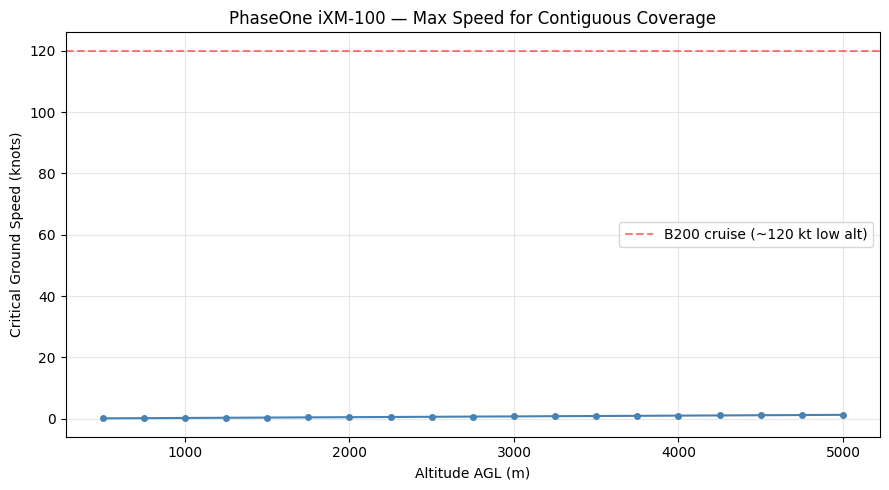

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

cgs_vals = [
    mapping_cam.critical_ground_speed(ureg.Quantity(a, "meter")).to(ureg.knot).magnitude
    for a in altitudes_m
]

ax.plot(altitudes_m, cgs_vals, "o-", markersize=4, color="steelblue")
ax.axhline(y=120, color="red", linestyle="--", alpha=0.5, label="B200 cruise (~120 kt low alt)")
ax.set_xlabel("Altitude AGL (m)")
ax.set_ylabel("Critical Ground Speed (knots)")
ax.set_title(f"{mapping_cam.name} — Max Speed for Contiguous Coverage")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Interpreting the plot above:** The rectangular footprint shows the ground area captured in a single frame at 2000 m AGL. The aspect ratio matches the sensor aspect ratio (53.4:40.0, or roughly 4:3). The nadir point (red cross) is at the center of the frame for a nadir-pointing camera. For tilted cameras (covered in the stereo/oblique notebook), the nadir point shifts toward one edge of the frame.

## 5. Focal Length Comparison

Changing the focal length trades off between GSD (resolution) and footprint (coverage).
A longer focal length gives finer resolution but a narrower field of view.

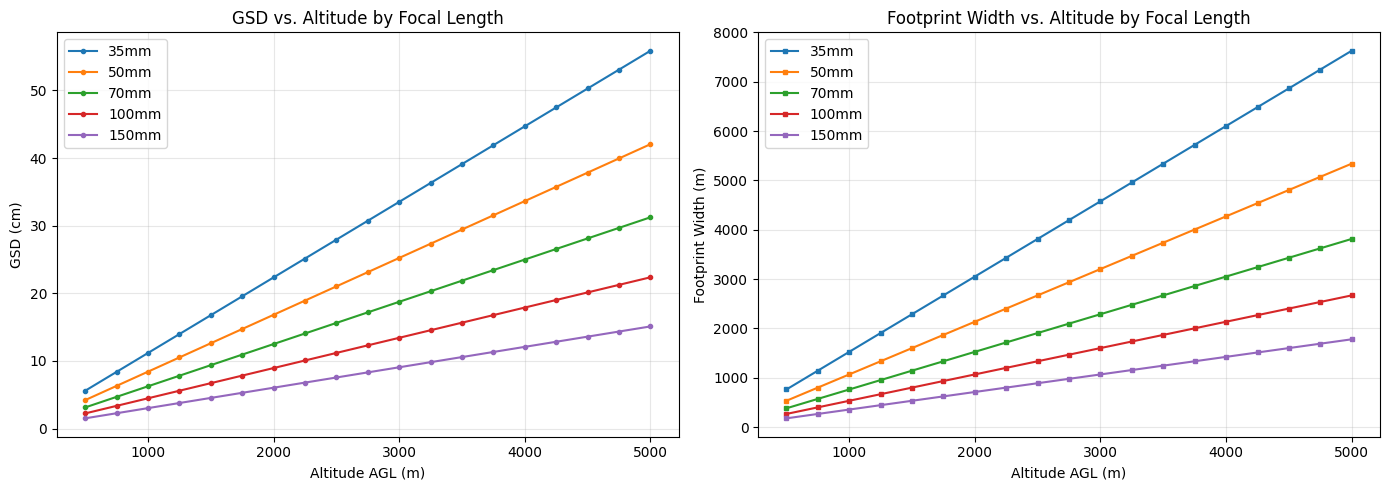

In [6]:
focal_lengths = [35, 50, 70, 100, 150]
cameras = {}

for fl in focal_lengths:
    cameras[f"{fl}mm"] = FrameCamera(
        name=f"Cam {fl}mm",
        sensor_width=ureg.Quantity(53.4, "mm"),
        sensor_height=ureg.Quantity(40.0, "mm"),
        focal_length=ureg.Quantity(fl, "mm"),
        resolution_x=11664,
        resolution_y=8750,
        frame_rate=ureg.Quantity(1.5, "Hz"),
        f_speed=4.0,
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, cam in cameras.items():
    gsd_vals = [
        cam.ground_sample_distance(ureg.Quantity(a, "meter"))["x"].to(ureg.cm).magnitude
        for a in altitudes_m
    ]
    fp_vals = [
        cam.footprint_at(ureg.Quantity(a, "meter"))["width"].to(ureg.meter).magnitude
        for a in altitudes_m
    ]
    axes[0].plot(altitudes_m, gsd_vals, "o-", markersize=3, label=label)
    axes[1].plot(altitudes_m, fp_vals, "s-", markersize=3, label=label)

axes[0].set_xlabel("Altitude AGL (m)")
axes[0].set_ylabel("GSD (cm)")
axes[0].set_title("GSD vs. Altitude by Focal Length")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Altitude AGL (m)")
axes[1].set_ylabel("Footprint Width (m)")
axes[1].set_title("Footprint Width vs. Altitude by Focal Length")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Common Pitfalls for Frame Camera Planning

- **Confusing GSD with mapping accuracy.** GSD is the pixel size on the ground, not the positional accuracy of the resulting map. Mapping accuracy depends on ground control points, GPS/IMU quality, and photogrammetric processing, and is typically 1-3x the GSD.
- **Ignoring forward overlap requirements.** Contiguous coverage (0% gap) is not the same as usable overlap. Photogrammetric software typically requires 60-80% forward overlap for reliable tie-point matching. Plan speeds accordingly.
- **Using footprint width for line spacing without accounting for side overlap.** Line spacing should be `footprint_width * (1 - side_overlap_fraction)`, not just `footprint_width`.
- **Forgetting that altitude is AGL, not MSL.** Over hilly terrain, the AGL altitude (and therefore GSD and footprint) varies along the flight line. Use terrain-aware planning for areas with significant relief.
- **Not accounting for motion blur at low altitudes.** At low altitude and high speed, the ground moves quickly across the sensor during exposure. Check that the image motion during the exposure time is less than 1 pixel (GSD / ground_speed < exposure_time).

## Operational Takeaways

- **Start from the GSD requirement.** Use `altitude_agl_for_ground_sample_distance()` to determine the flight altitude, then compute footprint and overlap from there.
- **Forward overlap is controlled by speed and frame rate.** To increase overlap without changing altitude, either slow down or increase the frame rate.
- **Side overlap is controlled by flight line spacing.** Compute line spacing as `footprint_width * (1 - desired_side_overlap)`.
- **Longer focal lengths give better resolution but require more flight lines.** This is the primary design tradeoff for frame camera surveys.
- **The critical ground speed is a hard ceiling.** Exceeding it means gaps between frames. In practice, plan for speeds well below the critical speed to achieve the required forward overlap.
- **Check exposure time constraints at low altitude.** Fast ground speeds and fine GSD can cause motion blur if the shutter speed is too slow.

## 6. Footprint Visualization

Visualize the ground footprint of the camera at a specific altitude,
showing the aspect ratio of the captured frame.

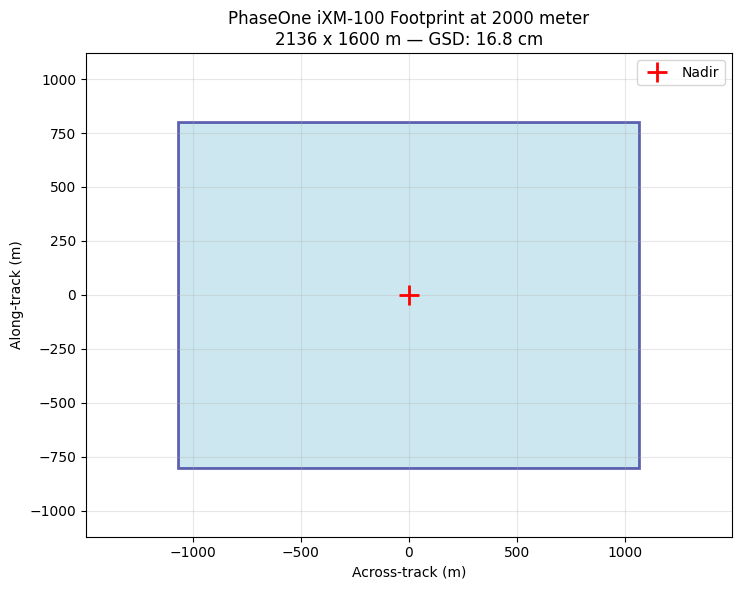

In [7]:
altitude = ureg.Quantity(2000, "meter")
fp = mapping_cam.footprint_at(altitude)
gsd = mapping_cam.ground_sample_distance(altitude)

w = fp["width"].to(ureg.meter).magnitude
h = fp["height"].to(ureg.meter).magnitude

fig, ax = plt.subplots(figsize=(8, 6))
rect = mpatches.Rectangle(
    (-w / 2, -h / 2), w, h,
    facecolor="lightblue", edgecolor="navy", linewidth=2, alpha=0.6,
)
ax.add_patch(rect)
ax.plot(0, 0, "r+", markersize=15, markeredgewidth=2, label="Nadir")

ax.set_xlim(-w * 0.7, w * 0.7)
ax.set_ylim(-h * 0.7, h * 0.7)
ax.set_aspect("equal")
ax.set_xlabel("Across-track (m)")
ax.set_ylabel("Along-track (m)")
ax.set_title(
    f"{mapping_cam.name} Footprint at {altitude}\n"
    f"{w:.0f} x {h:.0f} m — GSD: {gsd['x'].to(ureg.cm).magnitude:.1f} cm"
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Flight Line Integration

Compute coverage for a frame camera along a flight line. Each frame
captures a discrete footprint; we can calculate how many frames are
captured along the line at a given speed.

In [8]:
fl = FlightLine.center_length_azimuth(
    lat=34.4, lon=-119.8,
    length=ureg.Quantity(10, "km"),
    az=270.0,
    altitude_msl=ureg.Quantity(6500, "feet"),  # ~2000 m AGL
    site_name="Coastal Survey",
)

speed = ureg.Quantity(100, "knot")
altitude_agl = ureg.Quantity(2000, "meter")
fp = mapping_cam.footprint_at(altitude_agl)
gsd = mapping_cam.ground_sample_distance(altitude_agl)
cgs = mapping_cam.critical_ground_speed(altitude_agl)

# Number of frames along the line
line_length_m = fl.length.to(ureg.meter).magnitude
frame_period = (1 / mapping_cam.frame_rate).to(ureg.second).magnitude
speed_mps = speed.to(ureg.meter / ureg.second).magnitude
n_frames = int(line_length_m / (speed_mps * frame_period))
along_track_spacing = speed_mps * frame_period

print(f"Flight line: {fl.site_name}")
print(f"  Length:     {fl.length.to(ureg.km):.1f}")
print(f"  Speed:      {speed}")
print(f"  Alt AGL:    {altitude_agl}")
print(f"\nCamera performance:")
print(f"  GSD:                {gsd['x'].to(ureg.cm):.1f}")
print(f"  Footprint:          {fp['width'].to(ureg.meter):.0f} x {fp['height'].to(ureg.meter):.0f}")
print(f"  Critical speed:     {cgs.to(ureg.knot):.0f}")
print(f"  Frames captured:    {n_frames}")
print(f"  Along-track spacing: {along_track_spacing:.1f} m")
print(f"  Along-track overlap: {max(0, (1 - along_track_spacing / fp['height'].to(ureg.meter).magnitude)) * 100:.0f}%")

Flight line: Coastal Survey
  Length:     10.0 kilometer
  Speed:      100 knot
  Alt AGL:    2000 meter

Camera performance:
  GSD:                16.8 centimeter
  Footprint:          2136 meter x 1600 meter
  Critical speed:     1 knot
  Frames captured:    291
  Along-track spacing: 34.3 m
  Along-track overlap: 98%


## Summary

| Feature | Method/Property | Purpose |
|---------|----------------|----------|
| Camera definition | `FrameCamera(name, sensor_width, ...)` | Define camera optics and sensor |
| Field of view | `fov_x`, `fov_y` | Horizontal and vertical FOV |
| Ground sample distance | `ground_sample_distance(altitude)` | Pixel size on ground (x, y) |
| Altitude planning | `altitude_agl_for_ground_sample_distance(gsd_x, gsd_y)` | Required altitude for target GSD |
| Footprint | `footprint_at(altitude)` | Frame dimensions on ground |
| Speed limit | `critical_ground_speed(altitude)` | Max speed for contiguous frames |
| Terrain corners | `footprint_corners()` (static) | Ray-terrain intersection for corners |